In [13]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

import os

plt.rcParams["figure.figsize"] = (20, 7)

time_col = 'timestamp'
value_col = 'value'

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, parse_dates=[time_col])
df = df.set_index(time_col)

required_sensors = ['sensor_10', 'sensor_36', 'sensor_48']
missing_sensors = [s for s in required_sensors if s not in df.columns]
if missing_sensors:
    raise ValueError(f"Missing sensors in dataset: {missing_sensors}")

use_machine_status = 'machine_status' in df.columns
if use_machine_status:
    print("Using 'machine_status' for true anomalies (BROKEN or RECOVERING).")
else:
    print("No 'machine_status' column found. Using synthetic anomalies.")


Saving sensor.csv to sensor (1).csv
Using 'machine_status' for true anomalies (BROKEN or RECOVERING).


In [15]:
sensor_col = 'sensor_10'
df_sensor = df[[sensor_col, 'machine_status']].rename(columns={sensor_col: value_col}).copy()
df_sensor.dropna(inplace=True)

df_sensor['true_anomaly'] = df_sensor['machine_status'].isin(['BROKEN', 'RECOVERING']).astype(int)

df_sensor.drop(columns=['machine_status'], inplace=True)

df_sensor.head()


,value,true_anomaly
timestamp,,
2018-04-01 00:00:00,37.22740,0
2018-04-01 00:01:00,37.22740,0
2018-04-01 00:02:00,37.86777,0
2018-04-01 00:03:00,38.57977,0
2018-04-01 00:04:00,39.48939,0


from matplotlib import pyplot as plt
_df_0['value'].plot(kind='hist', bins=20, title='value')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['value']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'value'}, axis=1)
              .sort_values('value', ascending=True))
  xs = counted['value']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_1.sort_values('value', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('value')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['true_anomaly']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'true_anomaly'}, axis=1)
              .sort_values('true_anomaly', ascending=True))
  xs = counted['true_anomaly']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_2.sort_values('true_anomaly', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('true_anomaly')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_3['value'].plot(kind='line', figsize=(8, 4), title='value')
plt.gca().spines[['top', 'right']].set_visible(False)

In [16]:
def plot_data_anomalies(df, predicted_anomaly_array, title='Anomaly Detection'):
    plt.figure(figsize=(20, 7))
    plt.plot(df.index, df[value_col], linestyle='--', label='Sensor Reading')
    plt.scatter(df.index[df['true_anomaly'] == 1], df[value_col][df['true_anomaly'] == 1],
                color='green', label='True Anomalies', marker='x')
    plt.scatter(df.index[predicted_anomaly_array == 1], df[value_col][predicted_anomaly_array == 1],
                color='red', label='Predicted Anomalies', marker='o')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Sensor Value')
    plt.legend()
    plt.grid()
    plt.show()


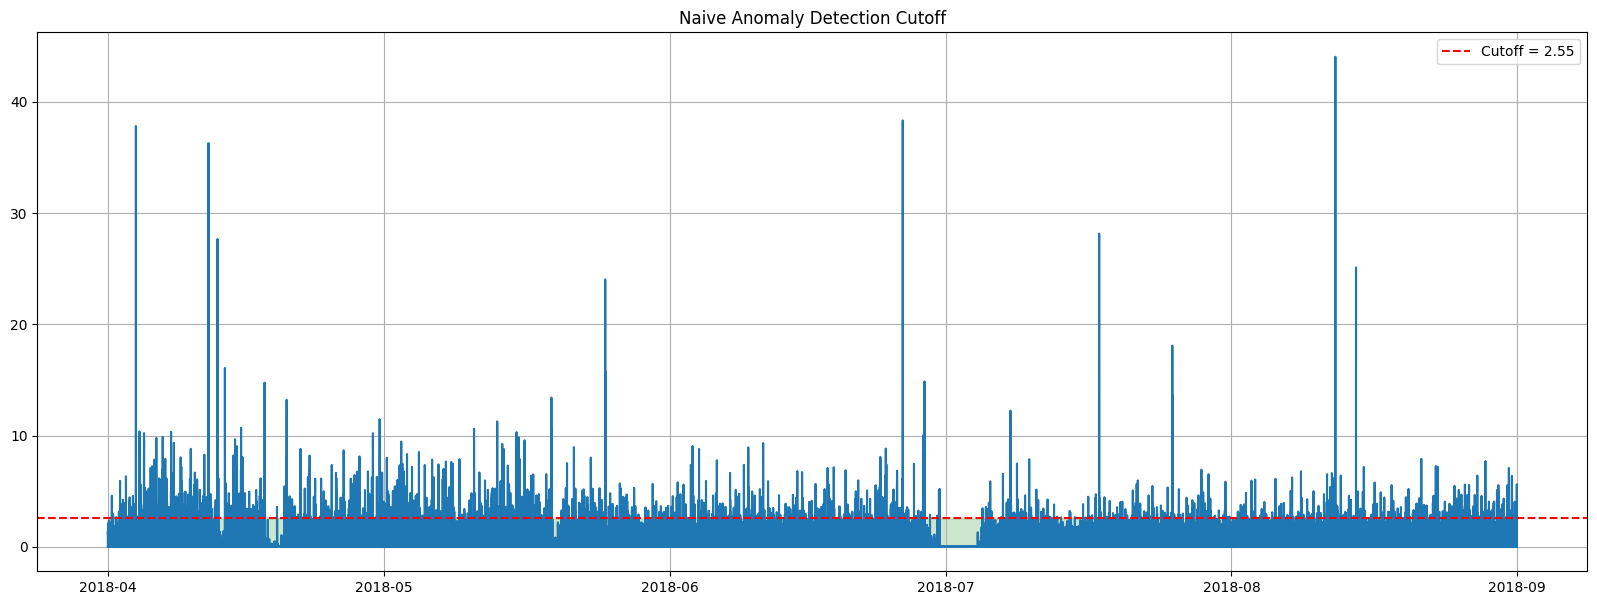

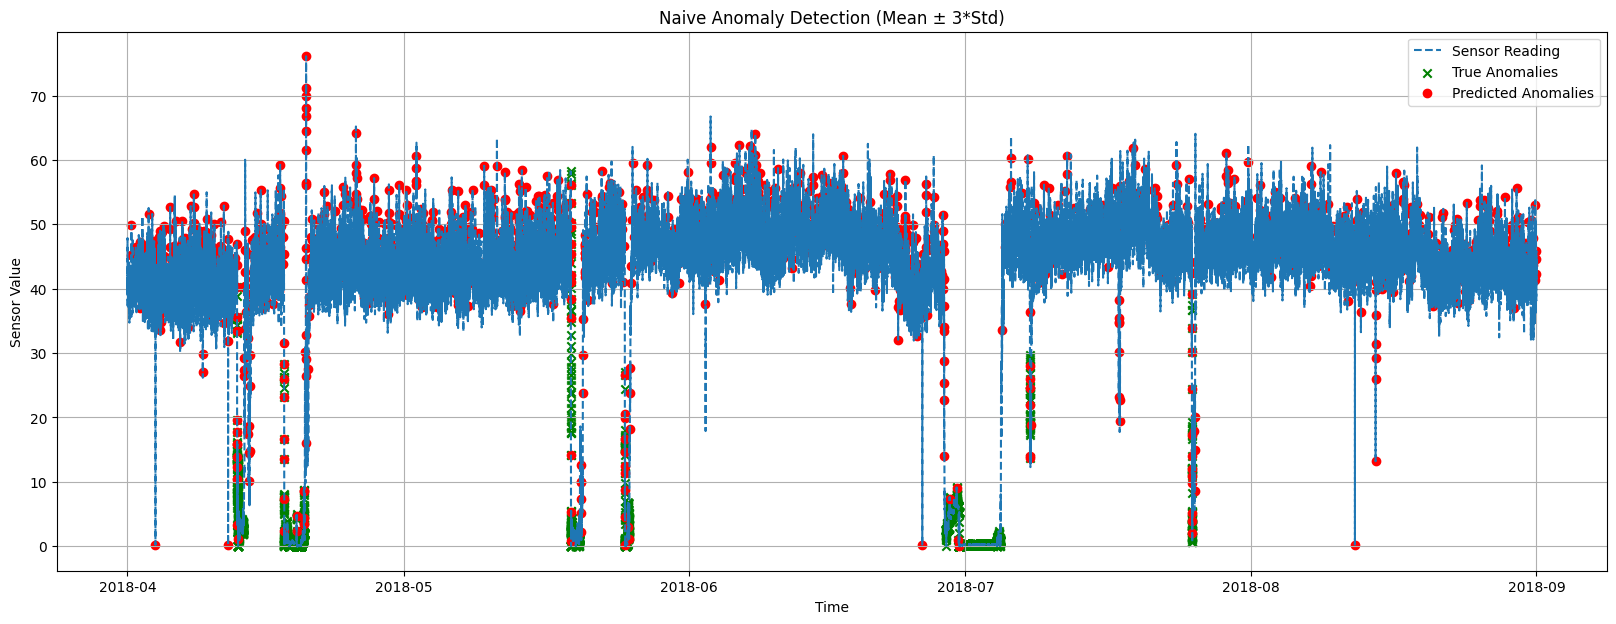

In [17]:
def detect_anomalies_naive(series, k=3, plot_cutoff=False):
    diff = np.abs(series.diff())
    mean = diff.mean()
    std = diff.std()
    cutoff = mean + k * std
    if plot_cutoff:
        plt.plot(diff)
        plt.axhline(y=cutoff, color='red', linestyle='--', label=f'Cutoff = {cutoff:.2f}')
        plt.fill_between(diff.index, 0, cutoff, alpha=0.2, color='green')
        plt.title("Naive Anomaly Detection Cutoff")
        plt.legend()
        plt.grid()
        plt.show()
    anomalies = (diff > cutoff).astype(int)
    return anomalies

naive_anomaly_array = detect_anomalies_naive(df_sensor[value_col], k=3, plot_cutoff=True)
plot_data_anomalies(df_sensor, naive_anomaly_array, title='Naive Anomaly Detection (Mean ± 3*Std)')


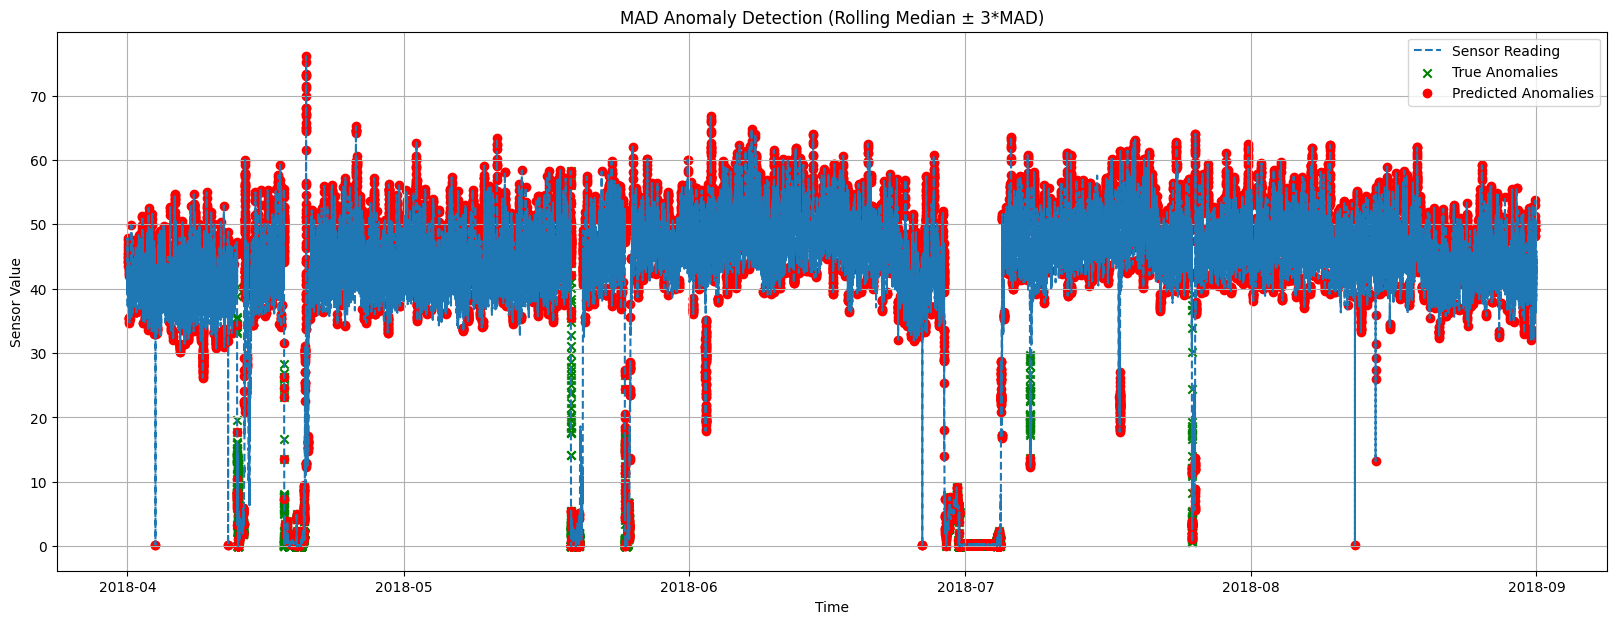

In [18]:
def detect_anomalies_mad(series, window_size=360, k=3):
    rolling_median = series.rolling(window=window_size, center=True, min_periods=1).median()
    residuals = np.abs(series - rolling_median)
    mad = residuals.rolling(window=window_size, center=True, min_periods=1).median()
    threshold = k * mad
    anomalies = (residuals > threshold).astype(int)
    return anomalies

mad_anomaly_array = detect_anomalies_mad(df_sensor[value_col], window_size=360, k=3)
plot_data_anomalies(df_sensor, mad_anomaly_array, title='MAD Anomaly Detection (Rolling Median ± 3*MAD)')


In [20]:
def evaluate(true_anomalies, predicted_anomalies, label='Method'):
    precision = precision_score(true_anomalies, predicted_anomalies, zero_division=0)
    recall = recall_score(true_anomalies, predicted_anomalies, zero_division=0)
    f1 = f1_score(true_anomalies, predicted_anomalies, zero_division=0)
    cm = confusion_matrix(true_anomalies, predicted_anomalies)

    print(f"\n{label} Confusion Matrix:\n{cm}")
    print(f"{label} Precision: {precision:.2f}")
    print(f"{label} Recall: {recall:.2f}")
    print(f"{label} F1 Score: {f1:.2f}")


evaluate(df_sensor['true_anomaly'], naive_anomaly_array, label='Naive')
evaluate(df_sensor['true_anomaly'], mad_anomaly_array, label='MAD')



Naive Confusion Matrix:
[[203496   2326]
 [ 14417     62]]
Naive Precision: 0.03
Naive Recall: 0.00
Naive F1 Score: 0.01

MAD Confusion Matrix:
[[192897  12925]
 [ 11972   2507]]
MAD Precision: 0.16
MAD Recall: 0.17
MAD F1 Score: 0.17



=== Processing sensor_36 ===


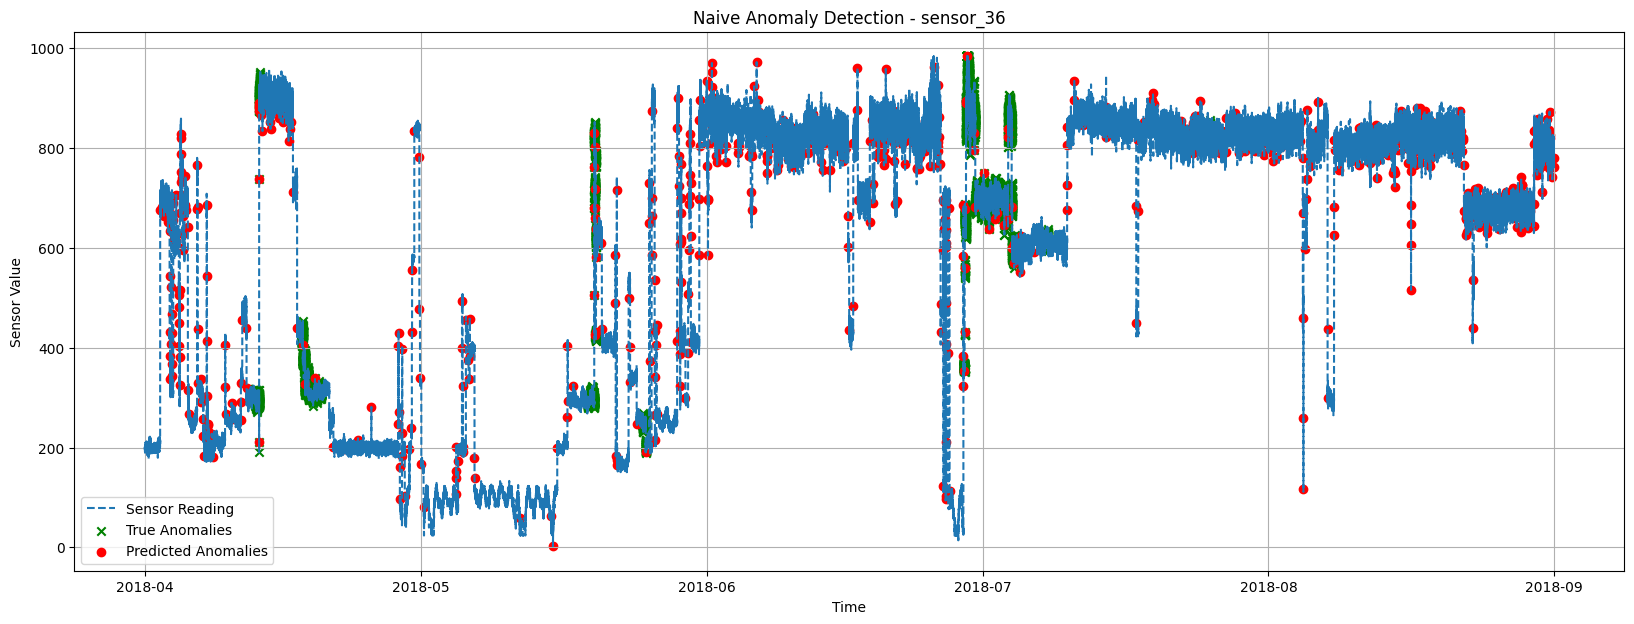


Naive - sensor_36 Confusion Matrix:
[[205027    793]
 [ 14440     44]]
Naive - sensor_36 Precision: 0.05
Naive - sensor_36 Recall: 0.00
Naive - sensor_36 F1 Score: 0.01


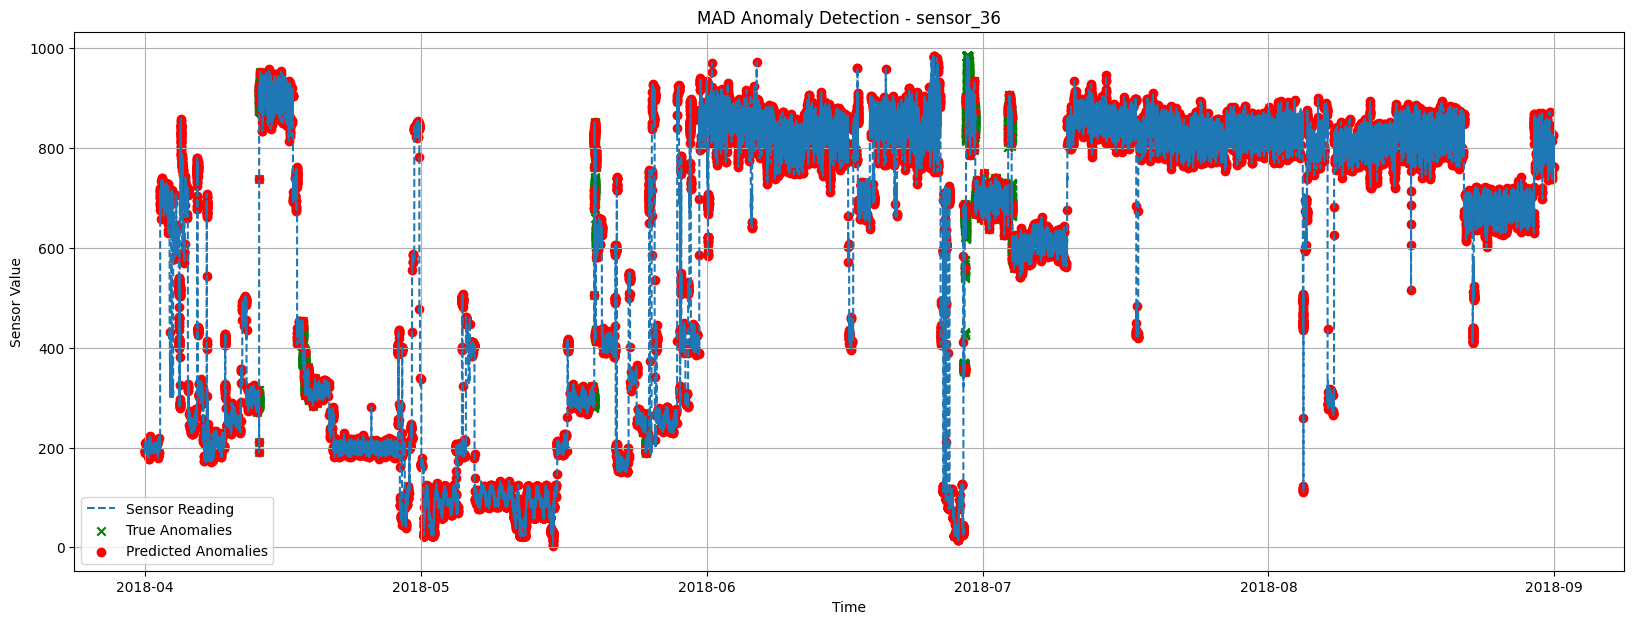


MAD - sensor_36 Confusion Matrix:
[[189552  16268]
 [ 13624    860]]
MAD - sensor_36 Precision: 0.05
MAD - sensor_36 Recall: 0.06
MAD - sensor_36 F1 Score: 0.05

=== Processing sensor_48 ===


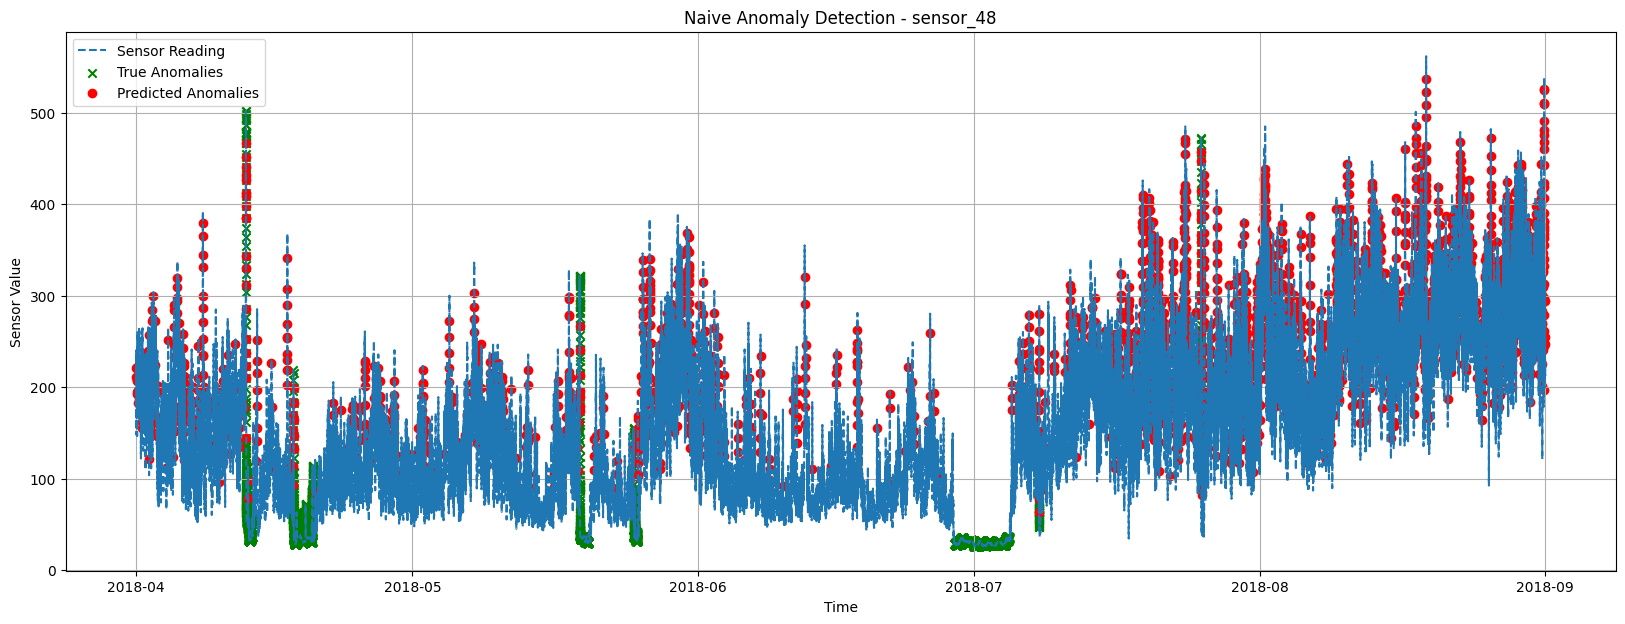


Naive - sensor_48 Confusion Matrix:
[[201969   3845]
 [ 14419     60]]
Naive - sensor_48 Precision: 0.02
Naive - sensor_48 Recall: 0.00
Naive - sensor_48 F1 Score: 0.01


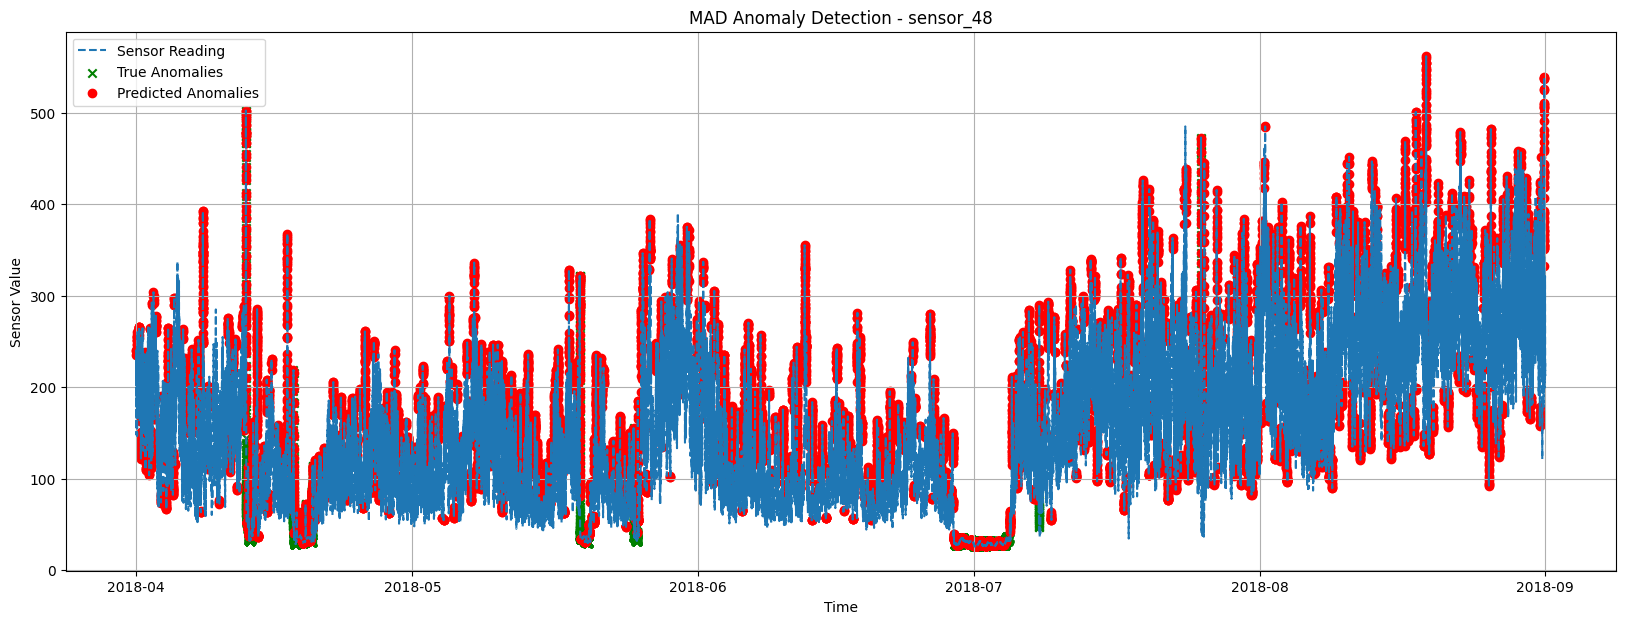


MAD - sensor_48 Confusion Matrix:
[[192813  13001]
 [ 10776   3703]]
MAD - sensor_48 Precision: 0.22
MAD - sensor_48 Recall: 0.26
MAD - sensor_48 F1 Score: 0.24


In [21]:
sensor_list = ['sensor_36', 'sensor_48']

for sensor_col in sensor_list:
    print(f"\n=== Processing {sensor_col} ===")
    df_sensor = df[[sensor_col, 'machine_status']].rename(columns={sensor_col: value_col}).copy()
    df_sensor.dropna(inplace=True)
    df_sensor['true_anomaly'] = df_sensor['machine_status'].isin(['BROKEN', 'RECOVERING']).astype(int)
    df_sensor.drop(columns=['machine_status'], inplace=True)

    # Naive Detection
    naive_anomaly_array = detect_anomalies_naive(df_sensor[value_col], k=3, plot_cutoff=False)
    plot_data_anomalies(df_sensor, naive_anomaly_array, title=f'Naive Anomaly Detection - {sensor_col}')
    evaluate(df_sensor['true_anomaly'], naive_anomaly_array, label=f'Naive - {sensor_col}')

    # MAD Detection
    mad_anomaly_array = detect_anomalies_mad(df_sensor[value_col], window_size=360, k=3)
    plot_data_anomalies(df_sensor, mad_anomaly_array, title=f'MAD Anomaly Detection - {sensor_col}')
    evaluate(df_sensor['true_anomaly'], mad_anomaly_array, label=f'MAD - {sensor_col}')
